# Custom GNN → Transformer Decoder Reaction Prediction

This notebook replaces the previous **GNN → MolT5 decoder** connection with a fully custom **end-to-end graph-to-sequence model**.

```text
USPTO reaction SMILES
→ RDKit/PyG reactant graph
→ GNN encoder
→ atom-level graph memory
→ custom Transformer decoder
→ product SMILES tokens
```

Key idea:
- Input side: atom graph tokens / graph nodes.
- Output side: product SMILES tokens.
- The GNN encoder and Transformer decoder are trained together from scratch.


## 0. Install packages

In [1]:
# Colab setup
%pip install rdkit
%pip install torch_geometric
%pip install transformers sentencepiece tensorboard
%pip install -q "ray[tune]"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 35.6 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 10.6 MB/s eta 0:00:00:00:0100:01


## 1. Imports and reproducibility

In [2]:
import os
import re
import math
import random
import glob
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_batch
from torch_geometric.nn import GINEConv, GATv2Conv, TransformerConv

from rdkit import Chem
from rdkit.Chem import Draw
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler


In [3]:
MAX_LEN = 128
BATCH_SIZE = 2 #4

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))


device: cuda
gpu: Tesla T4


## 2. SMILES → PyG molecular graph

Each atom becomes a graph node. Each bond becomes a graph edge.  
These graph nodes are the input **atom tokens** for the GNN encoder.


In [5]:
def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic())
    ]


def bond_features(bond):
    bond_type = bond.GetBondType()

    return [
        int(bond_type == Chem.rdchem.BondType.SINGLE),
        int(bond_type == Chem.rdchem.BondType.DOUBLE),
        int(bond_type == Chem.rdchem.BondType.TRIPLE),
        int(bond_type == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing())
    ]


def smiles_to_pyg_data(reactant_smiles):
    mol = Chem.MolFromSmiles(reactant_smiles)

    if mol is None:
        raise ValueError(f"Invalid reactant SMILES: {reactant_smiles}")

    x = [atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(x, dtype=torch.float)

    edge_index = []
    edge_attr = []

    for bond in mol.GetBonds():
        start = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()
        feat = bond_features(bond)

        edge_index.append([start, end])
        edge_index.append([end, start])
        edge_attr.append(feat)
        edge_attr.append(feat)

    if len(edge_index) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 6), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


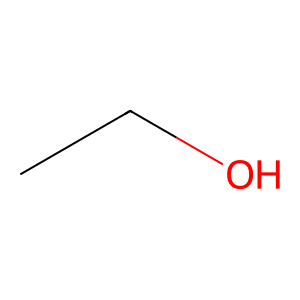

Data(x=[3, 4], edge_index=[2, 4], edge_attr=[4, 6])
x: torch.Size([3, 4])
edge_index: torch.Size([2, 4])
edge_attr: torch.Size([4, 6])


In [6]:
data = smiles_to_pyg_data("CCO")

mol = Chem.MolFromSmiles("CCO")

# Display the 2D molecule image directly
img = Draw.MolToImage(mol)
display(img)

print(data)
print("x:", data.x.shape)
print("edge_index:", data.edge_index.shape)
print("edge_attr:", data.edge_attr.shape)


## 3. Load USPTO-50K reactions

Expected folder structure:

```text
uspto50k/
  raw_train.csv
  raw_val.csv
  raw_test.csv
```

The loader tries to find a reaction SMILES column automatically.


In [7]:
def remove_atom_mapping(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(0)

    return Chem.MolToSmiles(mol, canonical=True)


def parse_uspto_reaction(rxn_smiles):
    parts = str(rxn_smiles).split(">")

    if len(parts) != 3:
        return None

    reactants, reagents, products = parts

    if reagents.strip():
        input_smiles = reactants + "." + reagents
    else:
        input_smiles = reactants

    input_smiles = remove_atom_mapping(input_smiles)
    product_smiles = remove_atom_mapping(products)

    if input_smiles is None or product_smiles is None:
        return None

    return {
        "reactants": input_smiles,
        "product": product_smiles
    }


def find_reaction_column(df):
    candidates = [
        "reactants>reagents>production",
        "reactants>reagents>products",
        "rxn_smiles",
        "reaction_smiles",
        "reaction"
    ]

    for col in candidates:
        if col in df.columns:
            return col

    for col in df.columns:
        sample = df[col].dropna().astype(str).head(20)
        if any(">" in x for x in sample):
            return col

    raise ValueError(f"Could not find reaction SMILES column. Columns: {list(df.columns)}")


def load_uspto_csv(csv_path, limit=None):
    df = pd.read_csv(csv_path)
    rxn_col = find_reaction_column(df)

    reactions = []

    for rxn in df[rxn_col]:
        parsed = parse_uspto_reaction(rxn)
        if parsed is not None:
            reactions.append(parsed)

        if limit is not None and len(reactions) >= limit:
            break

    return reactions


In [8]:
def sample_reactions(reactions, n, seed=42):
    rng = random.Random(seed)
    if n is None or n >= len(reactions):
        return reactions
    return rng.sample(reactions, n)

In [9]:
DATA_DIR = "uspto50k"

train_path = os.path.join(DATA_DIR, "raw_train.csv")
val_path = os.path.join(DATA_DIR, "raw_val.csv")
test_path = os.path.join(DATA_DIR, "raw_test.csv")

for p in [train_path, val_path, test_path]:
    print(p, os.path.exists(p))

TRAIN_LIMIT = 10000
VAL_LIMIT = 1000
TEST_LIMIT = 1000

#train_reactions = load_uspto_csv(train_path, limit=TRAIN_LIMIT)
#val_reactions = load_uspto_csv(val_path, limit=VAL_LIMIT)
#test_reactions = load_uspto_csv(test_path, limit=TEST_LIMIT)

all_train_reactions = load_uspto_csv(train_path, limit=None)
all_val_reactions = load_uspto_csv(val_path, limit=None)
all_test_reactions = load_uspto_csv(test_path, limit=None)

train_reactions = sample_reactions(all_train_reactions, TRAIN_LIMIT, seed=42)
val_reactions = sample_reactions(all_val_reactions, VAL_LIMIT, seed=43)
test_reactions = sample_reactions(all_test_reactions, TEST_LIMIT, seed=44)

print("train:", len(train_reactions))
print("val:", len(val_reactions))
print("test:", len(test_reactions))
print(train_reactions[0])


uspto50k/raw_train.csv True
uspto50k/raw_val.csv True
uspto50k/raw_test.csv True
train: 10000
val: 1000
test: 1000
{'reactants': 'CC(C)(C)[Si](C)(C)OCC1CCN(C(=O)C(F)(F)F)C1', 'product': 'O=C(N1CCC(CO)C1)C(F)(F)F'}


### Optional tiny overfit mode

In [10]:
# Uncomment this block for overfit debugging:
# train_reactions = load_uspto_csv(train_path, limit=100)
# val_reactions = train_reactions
# test_reactions = train_reactions
# print("OVERFIT MODE:", len(train_reactions))
#all_train_reactions = load_uspto_csv(train_path, limit=None)
#train_reactions = sample_reactions(all_train_reactions, 100, seed=42)
#val_reactions = sample_reactions(all_train_reactions, 100, seed=43)


## 4. Custom SMILES tokenizer

For the custom decoder, we build a product-SMILES vocabulary directly from the data.


In [11]:
SMILES_REGEX = r"(\[[^\]]+\]|Br|Cl|Si|Na|Li|Mg|Ca|Al|@@?|=|#|-|\+|\\|/|\(|\)|\.|:|~|@|\?|>|\*|\$|%[0-9]{2}|[0-9]|[A-Za-z])"

SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"


def tokenize_smiles(smiles):
    smiles = str(smiles)
    tokens = re.findall(SMILES_REGEX, smiles)

    if "".join(tokens) != smiles:
        raise ValueError(f"Tokenization failed: {smiles} -> {tokens}")

    return tokens


def build_vocab(smiles_list):
    token_set = set()

    for smi in smiles_list:
        token_set.update(tokenize_smiles(smi))

    tokens = SPECIAL_TOKENS + sorted(token_set)

    token_to_id = {tok: i for i, tok in enumerate(tokens)}
    id_to_token = {i: tok for tok, i in token_to_id.items()}

    return token_to_id, id_to_token


def encode_smiles(smiles, token_to_id, max_len=128):
    tokens = [SOS_TOKEN] + tokenize_smiles(smiles) + [EOS_TOKEN]

    ids = [token_to_id.get(tok, token_to_id[UNK_TOKEN]) for tok in tokens]

    if len(ids) > max_len:
        ids = ids[:max_len]
        ids[-1] = token_to_id[EOS_TOKEN]

    pad_id = token_to_id[PAD_TOKEN]
    ids = ids + [pad_id] * (max_len - len(ids))

    return torch.tensor(ids, dtype=torch.long)


def decode_ids(ids, id_to_token):
    if isinstance(ids, torch.Tensor):
        ids = ids.detach().cpu().tolist()

    tokens = []
    for idx in ids:
        tok = id_to_token[int(idx)]

        if tok == EOS_TOKEN:
            break
        if tok in [PAD_TOKEN, SOS_TOKEN]:
            continue

        tokens.append(tok)

    return "".join(tokens)


def clean_generated_smiles(smiles):
    if smiles is None:
        return ""

    smiles = str(smiles).replace(" ", "")

    for tok in ["<pad>", "</s>", "<s>", "<unk>", "[PAD]", "[EOS]", "[SOS]", "[UNK]"]:
        smiles = smiles.replace(tok, "")

    return smiles.strip()


def canonicalize_smiles(smiles):
    smiles = clean_generated_smiles(smiles)
    if smiles == "":
        return None

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return Chem.MolToSmiles(mol, canonical=True)


In [12]:
# Product-length filtering mode
# This keeps train/val/test separate but removes products longer than MAX_LEN.

def filter_by_product_len(reactions, max_len):
    filtered = []

    for r in reactions:
        product_len = len(tokenize_smiles(r["product"])) + 2  # SOS + EOS

        if product_len <= max_len:
            filtered.append(r)

    return filtered


short_train_reactions = filter_by_product_len(
    all_train_reactions,
    max_len=MAX_LEN
)
'''
train_reactions = sample_reactions(short_train_reactions, 50, seed=42)
val_reactions = train_reactions
test_reactions = train_reactions
'''

short_train_reactions = filter_by_product_len(all_train_reactions, MAX_LEN)
short_val_reactions = filter_by_product_len(all_val_reactions, MAX_LEN)
short_test_reactions = filter_by_product_len(all_test_reactions, MAX_LEN)

train_reactions = sample_reactions(short_train_reactions, TRAIN_LIMIT, seed=42)
val_reactions = sample_reactions(short_val_reactions, VAL_LIMIT, seed=43)
test_reactions = sample_reactions(short_test_reactions, TEST_LIMIT, seed=44)

In [13]:
print("GENERALIZATION MODE WITH LENGTH FILTERING")
print("short train pool:", len(short_train_reactions))
print("train:", len(train_reactions))
print("val:", len(val_reactions))
print("test:", len(test_reactions))

GENERALIZATION MODE WITH LENGTH FILTERING
short train pool: 39991
train: 10000
val: 1000
test: 1000


In [14]:
all_product_smiles = (
    [r["product"] for r in train_reactions] +
    [r["product"] for r in val_reactions] +
    [r["product"] for r in test_reactions]
)

token_to_id, id_to_token = build_vocab(all_product_smiles)

PAD_ID = token_to_id[PAD_TOKEN]
SOS_ID = token_to_id[SOS_TOKEN]
EOS_ID = token_to_id[EOS_TOKEN]
UNK_ID = token_to_id[UNK_TOKEN]

vocab_size = len(token_to_id)

print("vocab_size:", vocab_size)
print("special ids:", {"PAD": PAD_ID, "SOS": SOS_ID, "EOS": EOS_ID, "UNK": UNK_ID})
print("vocab sample:", list(token_to_id.items())[:30])


vocab_size: 66
special ids: {'PAD': 0, 'SOS': 1, 'EOS': 2, 'UNK': 3}
vocab sample: [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('#', 4), ('(', 5), (')', 6), ('-', 7), ('/', 8), ('1', 9), ('2', 10), ('3', 11), ('4', 12), ('5', 13), ('6', 14), ('7', 15), ('8', 16), ('9', 17), ('=', 18), ('B', 19), ('Br', 20), ('C', 21), ('Cl', 22), ('F', 23), ('I', 24), ('N', 25), ('O', 26), ('P', 27), ('S', 28), ('[C@@H]', 29)]


In [15]:
smi = train_reactions[0]["product"]
ids = encode_smiles(smi, token_to_id, max_len=128)
decoded = decode_ids(ids, id_to_token)

print("original:", smi)
print("decoded :", decoded)
print("canonical original:", canonicalize_smiles(smi))
print("canonical decoded :", canonicalize_smiles(decoded))


original: CN1CCCC(=O)C1=O
decoded : CN1CCCC(=O)C1=O
canonical original: CN1CCCC(=O)C1=O
canonical decoded : CN1CCCC(=O)C1=O


## 5. ReactionDataset and DataLoader

In [16]:
class ReactionDataset(Dataset):
    def __init__(self, reactions, token_to_id, max_len=128):
        self.reactions = reactions
        self.token_to_id = token_to_id
        self.max_len = max_len

    def __len__(self):
        return len(self.reactions)

    def __getitem__(self, idx):
        item = self.reactions[idx]

        reactants = item["reactants"]
        product = item["product"]

        data = smiles_to_pyg_data(reactants)

        product_ids = encode_smiles(
            product,
            self.token_to_id,
            self.max_len
        )
        # product_ids: [max_len]
        # [<SOS>, token1, token2, ..., <EOS>, <PAD>, ...]

        # Teacher forcing shift:
        # decoder_input_ids predicts decoder_target_ids one step ahead.
        decoder_input_ids = product_ids[:-1]
        decoder_target_ids = product_ids[1:]

        # Store as [1, max_len - 1] so PyG batches into [B, max_len - 1].
        data.decoder_input_ids = decoder_input_ids.unsqueeze(0)
        data.decoder_target_ids = decoder_target_ids.unsqueeze(0)

        # Keep full ids for debugging/EOS checks.
        data.product_ids = product_ids.unsqueeze(0)

        # Keep original strings for generation metrics and inspection.
        data.reactant_smiles = reactants
        data.target_smiles = product

        return data


In [17]:

train_dataset = ReactionDataset(train_reactions, token_to_id, max_len=MAX_LEN)
val_dataset = ReactionDataset(val_reactions, token_to_id, max_len=MAX_LEN)
test_dataset = ReactionDataset(test_reactions, token_to_id, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print(batch)
print("x:", batch.x.shape)
print("edge_index:", batch.edge_index.shape)
print("edge_attr:", batch.edge_attr.shape)
print("batch:", batch.batch.shape)
print("product_ids:", batch.product_ids.shape)
print("decoder_input_ids:", batch.decoder_input_ids.shape)
print("decoder_target_ids:", batch.decoder_target_ids.shape)
print("target_smiles example:", batch.target_smiles[0])

# EOS sanity check: decoder_target_ids should contain roughly one EOS per sample.
eos_count = (batch.decoder_target_ids == EOS_ID).sum().item()
print("EOS_ID:", EOS_ID)
print("EOS count in decoder_target_ids:", eos_count)

for ids in batch.decoder_target_ids[:3]:
    ids = ids.squeeze(0) if ids.dim() == 2 else ids
    print("target decoded:", decode_ids(ids, id_to_token))


DataBatch(x=[50, 4], edge_index=[2, 102], edge_attr=[102, 6], decoder_input_ids=[2, 127], decoder_target_ids=[2, 127], product_ids=[2, 128], reactant_smiles=[2], target_smiles=[2], batch=[50], ptr=[3])
x: torch.Size([50, 4])
edge_index: torch.Size([2, 102])
edge_attr: torch.Size([102, 6])
batch: torch.Size([50])
product_ids: torch.Size([2, 128])
decoder_input_ids: torch.Size([2, 127])
decoder_target_ids: torch.Size([2, 127])
target_smiles example: CC(C)C1NS(=O)(=O)N(COC(=O)c2c(Cl)cccc2Cl)C1=O
EOS_ID: 2
EOS count in decoder_target_ids: 2
target decoded: CC(C)C1NS(=O)(=O)N(COC(=O)c2c(Cl)cccc2Cl)C1=O
target decoded: CC(Oc1nc(Cl)cnc1NS(=O)(=O)c1cccc(Cl)c1Cl)C1CC1


## 6. GNN encoders

In [18]:
class GINEEncoder(nn.Module):
    def __init__(self, atom_dim=4, bond_dim=6, hidden_dim=256, num_layers=4, dropout=0.1):
        super().__init__()

        self.atom_proj = nn.Linear(atom_dim, hidden_dim)
        self.bond_proj = nn.Linear(bond_dim, hidden_dim)

        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.dropout = nn.Dropout(dropout)

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )

            self.layers.append(GINEConv(mlp))
            self.norms.append(nn.LayerNorm(hidden_dim))

    def forward(self, x, edge_index, edge_attr):
        h = self.atom_proj(x)

        if edge_attr.numel() > 0:
            edge_attr = self.bond_proj(edge_attr)
        else:
            edge_attr = edge_attr.new_empty((0, h.size(-1)))

        for conv, norm in zip(self.layers, self.norms):
            h_new = conv(h, edge_index, edge_attr)
            h = norm(h + self.dropout(h_new))

        return h


class GATv2Encoder(nn.Module):
    def __init__(self, atom_dim=4, bond_dim=6, hidden_dim=256, num_layers=4, heads=4, dropout=0.1):
        super().__init__()

        assert hidden_dim % heads == 0

        self.atom_proj = nn.Linear(atom_dim, hidden_dim)
        self.bond_proj = nn.Linear(bond_dim, hidden_dim)

        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.dropout = nn.Dropout(dropout)

        for _ in range(num_layers):
            conv = GATv2Conv(
                in_channels=hidden_dim,
                out_channels=hidden_dim // heads,
                heads=heads,
                concat=True,
                edge_dim=hidden_dim,
                dropout=dropout,
                add_self_loops=False
            )

            self.layers.append(conv)
            self.norms.append(nn.LayerNorm(hidden_dim))

    def forward(self, x, edge_index, edge_attr):
        h = self.atom_proj(x)

        if edge_attr.numel() > 0:
            edge_attr = self.bond_proj(edge_attr)
        else:
            edge_attr = edge_attr.new_empty((0, h.size(-1)))

        for conv, norm in zip(self.layers, self.norms):
            h_new = conv(h, edge_index, edge_attr)
            h = norm(h + self.dropout(h_new))

        return h


class GraphTransformerEncoder(nn.Module):
    def __init__(self, atom_dim=4, bond_dim=6, hidden_dim=256, num_layers=4, heads=4, dropout=0.1):
        super().__init__()

        assert hidden_dim % heads == 0

        self.atom_proj = nn.Linear(atom_dim, hidden_dim)
        self.bond_proj = nn.Linear(bond_dim, hidden_dim)

        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.dropout = nn.Dropout(dropout)

        for _ in range(num_layers):
            conv = TransformerConv(
                in_channels=hidden_dim,
                out_channels=hidden_dim // heads,
                heads=heads,
                concat=True,
                edge_dim=hidden_dim,
                dropout=dropout,
                beta=True
            )

            self.layers.append(conv)
            self.norms.append(nn.LayerNorm(hidden_dim))

    def forward(self, x, edge_index, edge_attr):
        h = self.atom_proj(x)

        if edge_attr.numel() > 0:
            edge_attr = self.bond_proj(edge_attr)
        else:
            edge_attr = edge_attr.new_empty((0, h.size(-1)))

        for conv, norm in zip(self.layers, self.norms):
            h_new = conv(h, edge_index, edge_attr)
            h = norm(h + self.dropout(h_new))

        return h


def build_gnn_encoder(encoder_type, atom_dim=4, bond_dim=6, hidden_dim=256, num_layers=4, heads=4, dropout=0.1):
    encoder_type = encoder_type.lower()

    if encoder_type == "gine":
        return GINEEncoder(atom_dim, bond_dim, hidden_dim, num_layers, dropout)
    if encoder_type == "gatv2":
        return GATv2Encoder(atom_dim, bond_dim, hidden_dim, num_layers, heads, dropout)
    if encoder_type == "transformer":
        return GraphTransformerEncoder(atom_dim, bond_dim, hidden_dim, num_layers, heads, dropout)

    raise ValueError(f"Unknown encoder_type: {encoder_type}")


## 7. Custom GNN → Transformer Decoder model

In [19]:
def is_valid_smiles(smiles):
    if smiles is None or len(smiles.strip()) == 0:
        return False

    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, hidden_dim, max_len=512, dropout=0.1):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, hidden_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, hidden_dim, 2).float() * (-math.log(10000.0) / hidden_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class GNNTransformerReactionModel(nn.Module):
    def __init__(
        self,
        gnn_encoder,
        vocab_size,
        hidden_dim=256,
        num_decoder_layers=4,
        num_heads=8,
        dropout=0.1,
        max_len=128,
        pad_id=0,
        sos_id=1,
        eos_id=2,
        id_to_token=None
    ):
        super().__init__()

        self.gnn = gnn_encoder
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.max_len = max_len
        self.pad_id = pad_id
        self.sos_id = sos_id
        self.eos_id = eos_id
        self.id_to_token = id_to_token

        self.token_embedding = nn.Embedding(
            vocab_size,
            hidden_dim,
            padding_idx=pad_id
        )

        self.positional_encoding = PositionalEncoding(
            hidden_dim=hidden_dim,
            max_len=max_len + 8,
            dropout=dropout
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_decoder_layers
        )

        self.output_head = nn.Linear(hidden_dim, vocab_size)

    def encode_graph(self, batch):
        atom_embeddings = self.gnn(
            batch.x,
            batch.edge_index,
            batch.edge_attr
        )

        memory, memory_mask = to_dense_batch(
            atom_embeddings,
            batch.batch
        )

        return memory, memory_mask

    def _make_causal_mask(self, seq_len, device):
        return torch.triu(
            torch.ones(seq_len, seq_len, device=device, dtype=torch.bool),
            diagonal=1
        )

    def _squeeze_if_pyg_batched(self, ids):
        # PyG can batch [1, T] per sample into [B, 1, T].
        if ids.dim() == 3:
            ids = ids.squeeze(1)
        return ids

    def decode(self, decoder_input_ids, memory, memory_mask):
        decoder_input_ids = self._squeeze_if_pyg_batched(decoder_input_ids)

        tgt = self.token_embedding(decoder_input_ids)
        tgt = self.positional_encoding(tgt)

        tgt_mask = self._make_causal_mask(
            decoder_input_ids.size(1),
            decoder_input_ids.device
        )

        tgt_key_padding_mask = decoder_input_ids.eq(self.pad_id)
        memory_key_padding_mask = ~memory_mask

        decoder_output = self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )

        logits = self.output_head(decoder_output)
        return logits

    def forward(self, batch):
        memory, memory_mask = self.encode_graph(batch)

        decoder_input_ids = self._squeeze_if_pyg_batched(batch.decoder_input_ids)
        decoder_target_ids = self._squeeze_if_pyg_batched(batch.decoder_target_ids)

        logits = self.decode(
            decoder_input_ids=decoder_input_ids,
            memory=memory,
            memory_mask=memory_mask
        )

        return logits, decoder_target_ids
    
    @torch.no_grad()
    def generate_ids_beam(
        self,
        batch,
        max_length=128,
        num_beams=3,
        length_penalty=0.7
    ):
        self.eval()

        memory, memory_mask = self.encode_graph(batch)

        batch_size = memory.size(0)
        device = memory.device

        all_generated = []

        for b in range(batch_size):
            single_memory = memory[b:b+1]
            single_memory_mask = memory_mask[b:b+1]

            # each beam = (token_ids_tensor, log_score, finished)
            beams = [
                (
                    torch.tensor([[self.sos_id]], dtype=torch.long, device=device),
                    0.0,
                    False
                )
            ]

            for _ in range(max_length - 1):
                new_beams = []

                for tokens, score, finished in beams:
                    if finished:
                        new_beams.append((tokens, score, True))
                        continue

                    logits = self.decode(
                        decoder_input_ids=tokens,
                        memory=single_memory,
                        memory_mask=single_memory_mask
                    )

                    next_token_logits = logits[:, -1, :]

                    # Do not generate PAD or SOS
                    next_token_logits[:, self.pad_id] = -1e9
                    next_token_logits[:, self.sos_id] = -1e9

                    log_probs = torch.log_softmax(next_token_logits, dim=-1)

                    top_log_probs, top_ids = torch.topk(
                        log_probs,
                        k=num_beams,
                        dim=-1
                    )

                    for i in range(num_beams):
                        next_id = top_ids[0, i].view(1, 1)
                        next_log_prob = top_log_probs[0, i].item()

                        new_tokens = torch.cat([tokens, next_id], dim=1)
                        new_score = score + next_log_prob
                        new_finished = next_id.item() == self.eos_id

                        new_beams.append(
                            (new_tokens, new_score, new_finished)
                        )

                # length-normalized score
                def normalize_score(beam):
                    tokens, score, finished = beam
                    length = tokens.size(1)
                    return score / (length ** length_penalty)

                new_beams = sorted(
                    new_beams,
                    key=normalize_score,
                    reverse=True
                )

                beams = new_beams[:num_beams]

                if all(finished for _, _, finished in beams):
                    break
            '''            
            best_tokens, best_score, best_finished = max(
                beams,
                key=lambda beam: beam[1] / (beam[0].size(1) ** length_penalty)
            )
            '''

            #=== Better final selection: prefer valid SMILES, then length-normalized score ===#
            valid_beams = []

            for tokens, score, finished in beams:
                smiles = decode_ids(tokens.squeeze(0).tolist(), self.id_to_token)

                if is_valid_smiles(smiles):
                    normalized_score = score / (tokens.size(1) ** length_penalty)
                    valid_beams.append((tokens, normalized_score, finished))

            if len(valid_beams) > 0:
                best_tokens, best_score, best_finished = max(
                    valid_beams,
                    key=lambda beam: beam[1]
                )
            else:
                best_tokens, best_score, best_finished = max(
                    beams,
                    key=lambda beam: beam[1] / (beam[0].size(1) ** length_penalty)
                )

            # Pad to max_length for batch output
            if best_tokens.size(1) < max_length:
                pad_len = max_length - best_tokens.size(1)
                pad = torch.full(
                    (1, pad_len),
                    self.pad_id,
                    dtype=torch.long,
                    device=device
                )
                best_tokens = torch.cat([best_tokens, pad], dim=1)
            else:
                best_tokens = best_tokens[:, :max_length]

            all_generated.append(best_tokens)

        return torch.cat(all_generated, dim=0)

    @torch.no_grad()
    def generate_smiles_beam(
        self,
        batch,
        max_length=128,
        num_beams=5
    ):
        generated_ids = self.generate_ids_beam(
            batch=batch,
            max_length=max_length,
            num_beams=num_beams
        )

        smiles_list = []

        for ids in generated_ids:
            smiles = decode_ids(ids.tolist(), self.id_to_token)
            smiles_list.append(smiles)

        return smiles_list

    @torch.no_grad()
    def generate_ids(self, batch, max_length=None, min_length=2, prevent_triple_repeat=True):
        self.eval()

        if max_length is None:
            max_length = self.max_len

        memory, memory_mask = self.encode_graph(batch)

        B = memory.size(0)
        device = memory.device

        generated = torch.full(
            (B, 1),
            fill_value=self.sos_id,
            dtype=torch.long,
            device=device
        )

        finished = torch.zeros(B, dtype=torch.bool, device=device)

        for step in range(max_length - 1):
            logits = self.decode(
                decoder_input_ids=generated,
                memory=memory,
                memory_mask=memory_mask
            )

            next_logits = logits[:, -1, :]

            # Never generate PAD or SOS inside a sequence.
            next_logits[:, self.pad_id] = -1e9
            next_logits[:, self.sos_id] = -1e9

            # Do not allow immediate EOS before a minimal length.
            if generated.size(1) < min_length:
                next_logits[:, self.eos_id] = -1e9

            # Simple repetition guard: if last 3 generated tokens are same,
            # block that token for the next step.
            if prevent_triple_repeat and generated.size(1) >= 3:
                last3 = generated[:, -3:]
                repeated = (last3[:, 0] == last3[:, 1]) & (last3[:, 1] == last3[:, 2])
                for b in torch.where(repeated)[0].tolist():
                    next_logits[b, last3[b, -1].item()] = -1e9

            next_token = torch.argmax(next_logits, dim=-1)

            # Once a sample has finished, keep appending EOS so shapes stay rectangular.
            next_token = torch.where(
                finished,
                torch.full_like(next_token, self.eos_id),
                next_token
            )

            generated = torch.cat([generated, next_token.unsqueeze(1)], dim=1)
            finished = finished | next_token.eq(self.eos_id)

            if finished.all():
                break

        return generated

    @torch.no_grad()
    def generate_smiles(self, batch, max_length=None):
        generated_ids = self.generate_ids(batch, max_length=max_length)

        smiles_list = []
        for row in generated_ids:
            smiles_list.append(decode_ids(row, self.id_to_token))

        return smiles_list


In [21]:
ENCODER_TYPE = "gine"  # options: "gine", "gatv2", "transformer"

HIDDEN_DIM = 256
NUM_GNN_LAYERS = 4
NUM_DECODER_LAYERS = 4
NUM_HEADS = 8
DROPOUT = 0.1

In [22]:
gnn_encoder = build_gnn_encoder(
    encoder_type=ENCODER_TYPE,
    atom_dim=4,
    bond_dim=6,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_GNN_LAYERS,
    heads=4,
    dropout=DROPOUT
)

model = GNNTransformerReactionModel(
    gnn_encoder=gnn_encoder,
    vocab_size=vocab_size,
    hidden_dim=HIDDEN_DIM,
    num_decoder_layers=NUM_DECODER_LAYERS,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
    max_len=MAX_LEN,
    pad_id=PAD_ID,
    sos_id=SOS_ID,
    eos_id=EOS_ID,
    id_to_token=id_to_token
).to(device)

print(model.__class__.__name__)
print("encoder:", ENCODER_TYPE)
print("parameters:", sum(p.numel() for p in model.parameters()))


GNNTransformerReactionModel
encoder: gine
parameters: 4779074


In [23]:
batch = next(iter(train_loader)).to(device)

logits, targets = model(batch)

print("logits:", logits.shape)
print("targets:", targets.shape)
print("target sample:", targets[0, :20])
print("EOS count in targets:", (targets == EOS_ID).sum().item())
print("generated before training:", model.generate_smiles(batch, max_length=64)[:3])


logits: torch.Size([2, 127, 66])
targets: torch.Size([2, 127])
target sample: tensor([21, 28,  5, 18, 26,  6,  5, 18, 26,  6, 26, 62,  9, 62, 62,  5, 21,  5,
        18, 26], device='cuda:0')
EOS count in targets: 2
generated before training: ['[Sn]44[S@][S@][S@]S[S@][S@]SSS[S@]SSS[S@]SSS[S@]SSS[S@]SS[S@]S[S@]S[S@]S[S@][S@]SS[S@][S@][S@]S[S@]SSS[S@]SSS[S@]SS[S@]#S[S@]SS[S@]S[S@][S@][S@]', '[Sn]44[S@][S@][S@]S[S@][S@]SSS[S@]SSS[S@]SSS[S@]SSS[S@]SSS[S@]S[S@]S[S@][S@]SSS[S@][S@][S@]S[S@]SSS[S@]SSS[S@]SS[S@]S[S@]SSS[S@]S[S@]S[S@]']


## 8. Metrics

In [24]:
def compute_token_accuracy(logits, labels, pad_id):
    preds = torch.argmax(logits, dim=-1)

    mask = labels != pad_id
    correct = (preds == labels) & mask

    total_correct = correct.sum().item()
    total_tokens = mask.sum().item()

    if total_tokens == 0:
        return 0.0

    return total_correct / total_tokens


def compute_valid_and_exact_match(pred_smiles_list, target_smiles_list):
    assert len(pred_smiles_list) == len(target_smiles_list)

    total = len(pred_smiles_list)
    valid_count = 0
    exact_match_count = 0

    for pred, target in zip(pred_smiles_list, target_smiles_list):
        pred_can = canonicalize_smiles(pred)
        target_can = canonicalize_smiles(target)

        if pred_can is not None:
            valid_count += 1

        if pred_can is not None and target_can is not None and pred_can == target_can:
            exact_match_count += 1

    valid_rate = valid_count / total if total > 0 else 0.0
    exact_match_acc = exact_match_count / total if total > 0 else 0.0

    return valid_rate, exact_match_acc


## 9. Training and evaluation functions

In [25]:
# Weighted loss: EOS is rare, but generation needs to learn when to stop.
# Increase EOS weight so the model is penalized more when it misses <EOS>.
EOS_WEIGHT = 2.0


def build_loss_criterion(eos_weight=2.0, device=device):
    loss_weights = torch.ones(vocab_size, device=device)
    loss_weights[EOS_ID] = float(eos_weight)

    return nn.CrossEntropyLoss(
        ignore_index=PAD_ID,
        weight=loss_weights
    )


criterion = build_loss_criterion(EOS_WEIGHT, device)


def train_one_epoch(model, train_loader, optimizer, device, epoch, writer=None):
    model.train()

    total_loss = 0.0
    total_token_acc = 0.0
    num_batches = 0

    for step, batch in enumerate(train_loader):
        batch = batch.to(device)

        logits, targets = model(batch)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1)
        )

        token_acc = compute_token_accuracy(logits, targets, pad_id=PAD_ID)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_token_acc += token_acc
        num_batches += 1

        global_step = epoch * len(train_loader) + step

        if writer is not None:
            writer.add_scalar("Train/Batch_Loss", loss.item(), global_step)
            writer.add_scalar("Train/Batch_Token_Accuracy", token_acc, global_step)

        if step % 20 == 0:
            print(
                f"Epoch {epoch + 1} | "
                f"Step {step}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f} | "
                f"Token Acc: {token_acc:.4f}"
            )

    return total_loss / num_batches, total_token_acc / num_batches


@torch.no_grad()
def evaluate_loss(model, data_loader, device):
    model.eval()

    total_loss = 0.0
    total_token_acc = 0.0
    num_batches = 0

    for batch in data_loader:
        batch = batch.to(device)

        logits, targets = model(batch)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1)
        )

        token_acc = compute_token_accuracy(logits, targets, pad_id=PAD_ID)

        total_loss += loss.item()
        total_token_acc += token_acc
        num_batches += 1

    return total_loss / num_batches, total_token_acc / num_batches


@torch.no_grad()
def evaluate_generation(model, data_loader, device, max_length=128, max_batches=None):
    model.eval()

    all_preds = []
    all_targets = []

    for batch_idx, batch in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        batch = batch.to(device)

        pred_smiles = model.generate_smiles(
            batch,
            max_length=max_length,
        )

        target_smiles = list(batch.target_smiles)

        all_preds.extend(pred_smiles)
        all_targets.extend(target_smiles)

    valid_rate, exact_match_acc = compute_valid_and_exact_match(
        all_preds,
        all_targets
    )

    return valid_rate, exact_match_acc, all_preds, all_targets


## 10. Ray Tune Hyperparameter Search

This section searches over model hyperparameters using Ray Tune. The search uses a smaller subset for speed, then the best configuration is used for final training on the selected training split.

In [26]:
# -------------------------------
# Ray Tune helper functions
# -------------------------------

RAY_NUM_SAMPLES = 6          # Increase to 10+ if you have more time
RAY_TUNE_EPOCHS = 8          # Increase to 15-20 for a better search
RAY_TUNE_TRAIN_LIMIT = 3000  # Smaller subset for faster tuning
RAY_TUNE_VAL_LIMIT = 300
RAY_GENERATION_EVAL_EVERY = 4
RAY_GENERATION_MAX_BATCHES = 5


def build_model_from_config(config, device):
    """Create a fresh GNN-Transformer model from one hyperparameter config."""
    encoder_type = config.get("encoder_type", "gine")
    hidden_dim = int(config["hidden_dim"])
    num_gnn_layers = int(config["num_gnn_layers"])
    num_decoder_layers = int(config["num_decoder_layers"])
    num_heads = int(config["num_heads"])
    dropout = float(config["dropout"])

    if hidden_dim % num_heads != 0:
        raise ValueError(f"hidden_dim={hidden_dim} must be divisible by num_heads={num_heads}")

    gnn_encoder = build_gnn_encoder(
        encoder_type=encoder_type,
        atom_dim=4,
        bond_dim=6,
        hidden_dim=hidden_dim,
        num_layers=num_gnn_layers,
        heads=num_heads,
        dropout=dropout
    )

    model = GNNTransformerReactionModel(
        gnn_encoder=gnn_encoder,
        vocab_size=vocab_size,
        hidden_dim=hidden_dim,
        num_decoder_layers=num_decoder_layers,
        num_heads=num_heads,
        dropout=dropout,
        max_len=MAX_LEN,
        pad_id=PAD_ID,
        sos_id=SOS_ID,
        eos_id=EOS_ID,
        id_to_token=id_to_token
    ).to(device)

    return model


def make_loaders_for_reactions(train_rxns, val_rxns, batch_size, max_len=MAX_LEN, shuffle_train=True):
    train_dataset_local = ReactionDataset(train_rxns, token_to_id, max_len=max_len)
    val_dataset_local = ReactionDataset(val_rxns, token_to_id, max_len=max_len)

    # num_workers=0 is safer inside Ray/Colab/Jupyter workers.
    train_loader_local = DataLoader(
        train_dataset_local,
        batch_size=int(batch_size),
        shuffle=shuffle_train,
        num_workers=0
    )
    val_loader_local = DataLoader(
        val_dataset_local,
        batch_size=int(batch_size),
        shuffle=False,
        num_workers=0
    )

    return train_loader_local, val_loader_local


def train_one_epoch_with_criterion(model, train_loader, optimizer, criterion_local, device):
    model.train()

    total_loss = 0.0
    total_token_acc = 0.0
    num_batches = 0

    for batch in train_loader:
        batch = batch.to(device)

        logits, targets = model(batch)
        loss = criterion_local(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1)
        )

        token_acc = compute_token_accuracy(logits, targets, pad_id=PAD_ID)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_token_acc += token_acc
        num_batches += 1

    return total_loss / max(num_batches, 1), total_token_acc / max(num_batches, 1)


@torch.no_grad()
def evaluate_loss_with_criterion(model, data_loader, criterion_local, device):
    model.eval()

    total_loss = 0.0
    total_token_acc = 0.0
    num_batches = 0

    for batch in data_loader:
        batch = batch.to(device)

        logits, targets = model(batch)
        loss = criterion_local(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1)
        )

        token_acc = compute_token_accuracy(logits, targets, pad_id=PAD_ID)

        total_loss += loss.item()
        total_token_acc += token_acc
        num_batches += 1

    return total_loss / max(num_batches, 1), total_token_acc / max(num_batches, 1)


def report_to_ray(metrics):
    """Compatibility wrapper for different Ray versions."""
    try:
        from ray import train as ray_train
        ray_train.report(metrics)
    except Exception:
        tune.report(metrics)


def ray_tune_trainable(config):
    trial_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    set_seed(42)

    # Use a smaller subset for tuning so trials finish in a reasonable time.
    tune_train_rxns = sample_reactions(
        train_reactions,
        min(RAY_TUNE_TRAIN_LIMIT, len(train_reactions)),
        seed=101
    )
    tune_val_rxns = sample_reactions(
        val_reactions,
        min(RAY_TUNE_VAL_LIMIT, len(val_reactions)),
        seed=102
    )

    train_loader_tune, val_loader_tune = make_loaders_for_reactions(
        tune_train_rxns,
        tune_val_rxns,
        batch_size=int(config["batch_size"]),
        max_len=MAX_LEN,
        shuffle_train=True
    )

    model_tune = build_model_from_config(config, trial_device)

    criterion_tune = build_loss_criterion(
        eos_weight=float(config["eos_weight"]),
        device=trial_device
    )

    optimizer_tune = torch.optim.AdamW(
        model_tune.parameters(),
        lr=float(config["lr"]),
        weight_decay=float(config["weight_decay"])
    )

    for epoch in range(RAY_TUNE_EPOCHS):
        train_loss, train_token_acc = train_one_epoch_with_criterion(
            model_tune,
            train_loader_tune,
            optimizer_tune,
            criterion_tune,
            trial_device
        )

        val_loss, val_token_acc = evaluate_loss_with_criterion(
            model_tune,
            val_loader_tune,
            criterion_tune,
            trial_device
        )

        # Generation metrics are slower, so evaluate them only every few epochs.
        if (epoch + 1) % RAY_GENERATION_EVAL_EVERY == 0 or epoch == RAY_TUNE_EPOCHS - 1:
            valid_rate, exact_match_acc, _, _ = evaluate_generation(
                model=model_tune,
                data_loader=val_loader_tune,
                device=trial_device,
                max_length=MAX_LEN,
                max_batches=RAY_GENERATION_MAX_BATCHES
            )
        else:
            valid_rate = 0.0
            exact_match_acc = 0.0

        # Exact match is the most important, valid SMILES is secondary, loss is tertiary.
        score = (exact_match_acc * 10.0) + valid_rate - (val_loss * 0.1)

        report_to_ray({
            "epoch": epoch + 1,
            "score": score,
            "train_loss": train_loss,
            "train_token_acc": train_token_acc,
            "val_loss": val_loss,
            "val_token_acc": val_token_acc,
            "valid_smiles_rate": valid_rate,
            "canonical_exact_match": exact_match_acc,
        })

    del model_tune
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [ ]:
# -------------------------------
# Run Ray Tune search
# -------------------------------

ray.shutdown()
ray.init(ignore_reinit_error=True, include_dashboard=False, log_to_driver=False)

ray_search_space = {
    "encoder_type": "gine",
    "hidden_dim": tune.choice([128, 256]),
    "num_gnn_layers": tune.choice([2, 3, 4]),
    "num_decoder_layers": tune.choice([2, 3, 4]),
    "num_heads": tune.choice([4, 8]),
    "dropout": tune.choice([0.1, 0.2, 0.3]),
    "lr": tune.loguniform(5e-5, 3e-4),
    "weight_decay": tune.choice([1e-5, 1e-4]),
    "eos_weight": tune.choice([1.0, 1.5, 2.0]),
    "batch_size": tune.choice([4, 8, 16]),
}

RAY_RESULTS_DIR = os.path.abspath("ray_results")

scheduler = ASHAScheduler(
    max_t=RAY_TUNE_EPOCHS,
    grace_period=3,
    reduction_factor=2
)

resources_per_trial = {
    "cpu": 2,
    "gpu": 1 if torch.cuda.is_available() else 0
}

analysis = tune.run(
    ray_tune_trainable,
    config=ray_search_space,
    num_samples=RAY_NUM_SAMPLES,
    metric="score",
    mode="max",
    scheduler=scheduler,
    storage_path=RAY_RESULTS_DIR,
    resources_per_trial={"cpu": 2, "gpu": 1},
)

best_config = analysis.get_best_config(metric="score", mode="max")
print("Best config:")
print(best_config)

ray_results_df = analysis.results_df.sort_values("score", ascending=False)

show_cols = [
    "score",
    "val_loss",
    "val_token_acc",
    "valid_smiles_rate",
    "canonical_exact_match",
    "config/hidden_dim",
    "config/num_gnn_layers",
    "config/num_decoder_layers",
    "config/num_heads",
    "config/dropout",
    "config/lr",
    "config/eos_weight",
    "config/batch_size",
]

show_cols = [c for c in show_cols if c in ray_results_df.columns]
display(ray_results_df[show_cols].head(10))


2026-06-12 03:53:15,563	INFO worker.py:2012 -- Started a local Ray instance.


ValueError: You passed a `metric` or `mode` argument to `tune.run(...)`, but the scheduler you are using was already instantiated with their own `metric` and `mode` parameters. Either remove the arguments from your scheduler or from `tune.run(...)` args.

## 11. Final Training with Best Ray Tune Configuration

This section rebuilds the model using the best Ray Tune hyperparameters, trains it on the selected training set, saves the best checkpoint, and stores training history for plotting.

In [ ]:
# -------------------------------
# Train final model using the best Ray Tune config
# -------------------------------

FINAL_NUM_EPOCHS = 30
FINAL_GENERATION_EVAL_EVERY = 1
FINAL_GENERATION_MAX_BATCHES = 25


def run_final_training(best_config, num_epochs=FINAL_NUM_EPOCHS):
    global model, optimizer, criterion, writer, history
    global ENCODER_TYPE, HIDDEN_DIM, NUM_GNN_LAYERS, NUM_DECODER_LAYERS, NUM_HEADS, DROPOUT, BATCH_SIZE, EOS_WEIGHT
    global train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset

    ENCODER_TYPE = best_config.get("encoder_type", "gine")
    HIDDEN_DIM = int(best_config["hidden_dim"])
    NUM_GNN_LAYERS = int(best_config["num_gnn_layers"])
    NUM_DECODER_LAYERS = int(best_config["num_decoder_layers"])
    NUM_HEADS = int(best_config["num_heads"])
    DROPOUT = float(best_config["dropout"])
    BATCH_SIZE = int(best_config["batch_size"])
    EOS_WEIGHT = float(best_config["eos_weight"])

    # Rebuild loaders with the tuned batch size.
    train_dataset = ReactionDataset(train_reactions, token_to_id, max_len=MAX_LEN)
    val_dataset = ReactionDataset(val_reactions, token_to_id, max_len=MAX_LEN)
    test_dataset = ReactionDataset(test_reactions, token_to_id, max_len=MAX_LEN)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Rebuild model using best config.
    model = build_model_from_config(best_config, device)

    criterion = build_loss_criterion(
        eos_weight=EOS_WEIGHT,
        device=device
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(best_config["lr"]),
        weight_decay=float(best_config["weight_decay"])
    )

    log_dir = f"runs/ray_tuned_gnn_transformer_{ENCODER_TYPE}"
    writer = SummaryWriter(log_dir=log_dir)

    history = {
        "train_loss": [],
        "train_token_acc": [],
        "val_loss": [],
        "val_token_acc": [],
        "valid_smiles_rate": [],
        "canonical_exact_match": [],
        "score": [],
    }

    best_score = -float("inf")
    best_checkpoint_path = f"checkpoints/best_ray_tuned_custom_gnn_transformer_{ENCODER_TYPE}.pt"
    os.makedirs("checkpoints", exist_ok=True)

    for epoch in range(num_epochs):
        print(f"\n===== Final Training Epoch {epoch + 1}/{num_epochs} =====")

        train_loss, train_token_acc = train_one_epoch(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            device=device,
            epoch=epoch,
            writer=writer
        )

        val_loss, val_token_acc = evaluate_loss(
            model=model,
            data_loader=val_loader,
            device=device
        )

        if (epoch + 1) % FINAL_GENERATION_EVAL_EVERY == 0 or epoch == num_epochs - 1:
            valid_rate, exact_match_acc, preds, targets = evaluate_generation(
                model=model,
                data_loader=val_loader,
                device=device,
                max_length=MAX_LEN,
                max_batches=FINAL_GENERATION_MAX_BATCHES
            )
        else:
            valid_rate = 0.0
            exact_match_acc = 0.0
            preds, targets = [], []

        score = (exact_match_acc * 10.0) + valid_rate - (val_loss * 0.1)

        history["train_loss"].append(train_loss)
        history["train_token_acc"].append(train_token_acc)
        history["val_loss"].append(val_loss)
        history["val_token_acc"].append(val_token_acc)
        history["valid_smiles_rate"].append(valid_rate)
        history["canonical_exact_match"].append(exact_match_acc)
        history["score"].append(score)

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Token Acc: {train_token_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Token Acc: {val_token_acc:.4f} | "
            f"Valid SMILES: {valid_rate:.4f} | "
            f"Canonical Exact Match: {exact_match_acc:.4f} | "
            f"Score: {score:.4f}"
        )

        if len(preds) > 0:
            print("\nSample predictions:")
            for i in range(min(3, len(preds))):
                print("PRED  :", preds[i])
                print("TARGET:", targets[i])
                print()

        writer.add_scalar("Epoch/Train_Loss", train_loss, epoch)
        writer.add_scalar("Epoch/Train_Token_Accuracy", train_token_acc, epoch)
        writer.add_scalar("Epoch/Val_Loss", val_loss, epoch)
        writer.add_scalar("Epoch/Val_Token_Accuracy", val_token_acc, epoch)
        writer.add_scalar("Epoch/Valid_SMILES_Rate", valid_rate, epoch)
        writer.add_scalar("Epoch/Canonical_Exact_Match", exact_match_acc, epoch)
        writer.add_scalar("Epoch/Score", score, epoch)
        writer.flush()

        if score > best_score:
            best_score = score

            torch.save(
                {
                    "epoch": epoch,
                    "encoder_type": ENCODER_TYPE,
                    "config": dict(best_config),
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "score": score,
                    "val_loss": val_loss,
                    "val_token_acc": val_token_acc,
                    "valid_smiles_rate": valid_rate,
                    "canonical_exact_match": exact_match_acc,
                    "token_to_id": token_to_id,
                    "id_to_token": id_to_token,
                    "max_len": MAX_LEN,
                },
                best_checkpoint_path
            )

            print("Saved best Ray-tuned model:", best_checkpoint_path)

    writer.close()

    print("\nBest final training score:", best_score)
    print("Best checkpoint:", best_checkpoint_path)

    return model, history, best_checkpoint_path


model, history, best_checkpoint_path = run_final_training(best_config, num_epochs=FINAL_NUM_EPOCHS)


## 12. Final Evaluation and Prediction Inspection

This cell evaluates the Ray-tuned final model and displays input, predicted product, and target product examples.

In [ ]:
@torch.no_grad()
def evaluate_generation_with_inputs(model, data_loader, device, max_length=128, max_batches=None):
    model.eval()

    all_inputs = []
    all_preds = []
    all_targets = []

    for batch_idx, batch in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        batch = batch.to(device)

        pred_smiles = model.generate_smiles(
            batch,
            max_length=max_length
        )

        all_inputs.extend(list(batch.reactant_smiles))
        all_preds.extend(pred_smiles)
        all_targets.extend(list(batch.target_smiles))

    valid_rate, exact_match_acc = compute_valid_and_exact_match(
        all_preds,
        all_targets
    )

    return valid_rate, exact_match_acc, all_inputs, all_preds, all_targets


val_valid_rate, val_exact_match_acc, val_inputs, val_preds, val_targets = evaluate_generation_with_inputs(
    model=model,
    data_loader=val_loader,
    device=device,
    max_length=MAX_LEN,
    max_batches=25
)

print("Validation Valid SMILES Rate:", val_valid_rate)
print("Validation Canonical Exact Match:", val_exact_match_acc)

# Test evaluation can be slower. Increase max_batches or set to None for full test evaluation.
test_valid_rate, test_exact_match_acc, test_inputs, test_preds, test_targets = evaluate_generation_with_inputs(
    model=model,
    data_loader=test_loader,
    device=device,
    max_length=MAX_LEN,
    max_batches=25
)

print("Test Valid SMILES Rate:", test_valid_rate)
print("Test Canonical Exact Match:", test_exact_match_acc)

prediction_df = pd.DataFrame({
    "input_reactants": val_inputs,
    "predicted_product": val_preds,
    "target_product": val_targets,
    "pred_canonical": [canonicalize_smiles(p) for p in val_preds],
    "target_canonical": [canonicalize_smiles(t) for t in val_targets],
})

prediction_df["exact_match"] = prediction_df["pred_canonical"] == prediction_df["target_canonical"]
prediction_df.to_csv("ray_tuned_validation_predictions.csv", index=False)

display(prediction_df.head(20))
print("Saved predictions to ray_tuned_validation_predictions.csv")


## 11.5 EOS and target sanity checks


In [ ]:
# Run this after dataset/model creation, and again after training.
# It verifies that EOS exists in the target and checks whether generation stops.

batch = next(iter(train_loader))
print("batch keys:", batch.keys())
print("decoder_input_ids shape:", batch.decoder_input_ids.shape)
print("decoder_target_ids shape:", batch.decoder_target_ids.shape)
print("EOS_ID:", EOS_ID)
print("EOS count in decoder_target_ids:", (batch.decoder_target_ids == EOS_ID).sum().item())

for ids in batch.decoder_target_ids[:3]:
    ids = ids.squeeze(0) if ids.dim() == 2 else ids
    print("target decoded:", decode_ids(ids, id_to_token))

batch = batch.to(device)
pred_ids = model.generate_ids(batch, max_length=MAX_LEN)
print("\nGenerated EOS check:")
for ids in pred_ids[:5]:
    print("EOS count:", (ids == EOS_ID).sum().item())
    print("decoded:", decode_ids(ids, id_to_token))
    print()


batch keys: ['ptr', 'target_smiles', 'decoder_input_ids', 'decoder_target_ids', 'edge_attr', 'x', 'reactant_smiles', 'edge_index', 'batch', 'product_ids']
decoder_input_ids shape: torch.Size([2, 127])
decoder_target_ids shape: torch.Size([2, 127])
EOS_ID: 2
EOS count in decoder_target_ids: 2
target decoded: O=C(O)c1ccc(C(=O)CCC(=O)c2ccccc2)cc1
target decoded: CCOC(=O)CC1CCCc2c1[nH]c1c(Br)cc(F)cc21

Generated EOS check:
EOS count: 1
decoded: CCOC(=O)CCC(c1ccc(C(=O)OC)cc1)c1ccc(C(=O)O)ccc1

EOS count: 9
decoded: CCOC(=O)CC1CCCN(c2ccc(F)c(F)c2OCCC2)CC1



## 12. Plot curves without TensorBoard

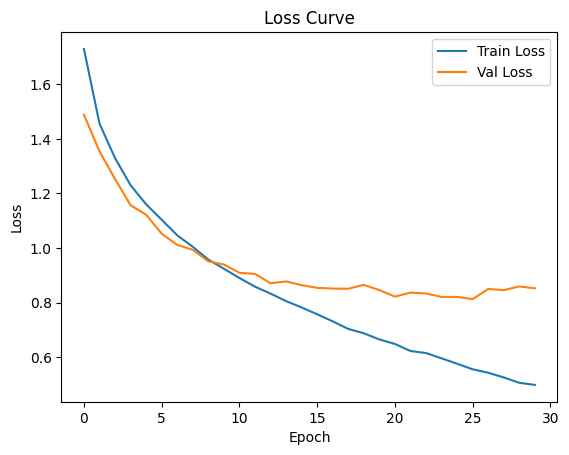

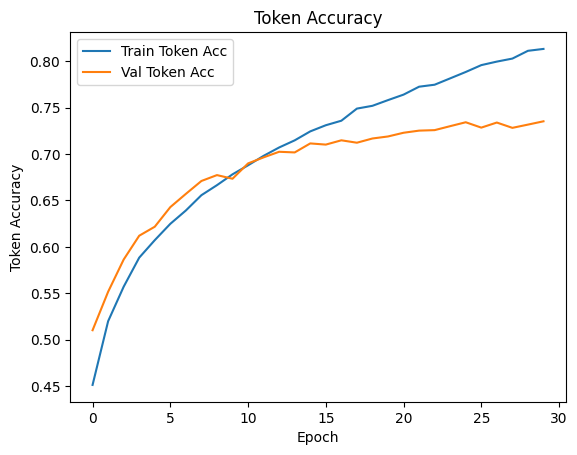

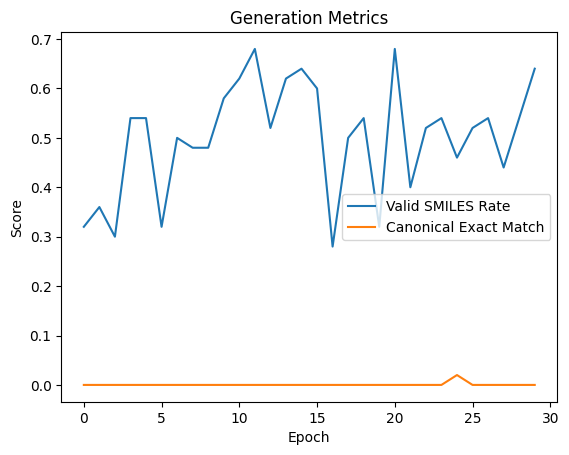

In [ ]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(history["train_token_acc"], label="Train Token Acc")
plt.plot(history["val_token_acc"], label="Val Token Acc")
plt.xlabel("Epoch")
plt.ylabel("Token Accuracy")
plt.legend()
plt.title("Token Accuracy")
plt.show()

plt.figure()
plt.plot(history["valid_smiles_rate"], label="Valid SMILES Rate")
plt.plot(history["canonical_exact_match"], label="Canonical Exact Match")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("Generation Metrics")
plt.show()


## 13. Inspect predictions

In [ ]:
# Corrected prediction inspection: inputs, predictions, and targets come from the same data loader.
valid_rate, exact_match_acc, inputs, preds, targets = evaluate_generation_with_inputs(
    model=model,
    data_loader=val_loader,
    device=device,
    max_length=MAX_LEN,
    max_batches=10
)

print("Valid SMILES Rate:", valid_rate)
print("Canonical Exact Match:", exact_match_acc)

for i in range(min(20, len(preds))):
    print("INPUT :", inputs[i])
    print("PRED  :", preds[i])
    print("TARGET:", targets[i])
    print("PRED can  :", canonicalize_smiles(preds[i]))
    print("TARGET can:", canonicalize_smiles(targets[i]))
    print()


[21:56:14] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)OC(=O)N1CCCC(C2)CC1'
[21:56:14] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)OC(=O)N1CCC(C2)CCC1'
[21:56:14] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)OC(=O)N1CCCC(C2)CC(N(C3CCC(=O)OC(C)(C)C)C2)CC1'
[21:56:16] SMILES Parse Error: extra close parentheses while parsing: N#Cc1ccc(-c2cccc3c2)cc1CNC(=O)Cc2ccccc2)C1
[21:56:16] SMILES Parse Error: check for mistakes around position 40:
[21:56:16] )cc1CNC(=O)Cc2ccccc2)C1
[21:56:16] ~~~~~~~~~~~~~~~~~~~~^
[21:56:16] SMILES Parse Error: Failed parsing SMILES 'N#Cc1ccc(-c2cccc3c2)cc1CNC(=O)Cc2ccccc2)C1' for input: 'N#Cc1ccc(-c2cccc3c2)cc1CNC(=O)Cc2ccccc2)C1'
[21:56:16] SMILES Parse Error: extra close parentheses while parsing: N#Cc1ccc(-c2ccccc2)c2ccc(CN3C(=O)C3)ccc2)c1
[21:56:16] SMILES Parse Error: check for mistakes around position 41:
[21:56:16] 2ccc(CN3C(=O)C3)ccc2)c1
[21:56:16] ~~~~~~~~~~~~~~~~~~~~^
[21:56:16] SMILES Parse Error: Failed parsing SMILES 'N#Cc

Valid SMILES Rate: 0.65
Canonical Exact Match: 0.0
INPUT : Cc1n[nH]c(=O)[nH]c1=O.ClCCCCBr
PRED  : CC(C)(C)OC(=O)N1CCCC(C2)CC1
TARGET: CC(C)(C)OC(=O)N1CCC(N2C(=O)CO[C@H]3CCCC[C@@H]32)CC1

INPUT : ClCCC12CCCN1CCC2.O=CNc1ccccc1
PRED  : N#Cc1ccc(-c2cccc3c2)cc1CNC(=O)Cc2ccccc2)C1
TARGET: O=C1Nc2ccccc2/C1=C\c1ccc2[nH]nnc2c1

INPUT : BrCCCCBr.OC1CCCC1
PRED  : COC(=O)CNC(=O)c1ccc(CN2CCN(Cc3cccc(Cl)c3)CC3)cc2c1
TARGET: COCCOCc1cccc2c1nc(C(=O)NC1CCN(C(C)C)CC1)n2CC(=O)Nc1ccc(Cl)cn1

INPUT : CC(C)CC(C)(C)C[C@H](CC(=O)N1CCOCC1)C(=O)O.CC[C@H](N)C(=O)c1ncco1
PRED  : CC(C)(C)OC(=O)CC(C)(C)C(C)C(=O)c1ccccc1
TARGET: C[C@H](N)C(=O)NC(C)(C)c1ccccc1

INPUT : CCCCCc1c(-c2ccccc2)n(Cc2ccccc2)c2ccc(-c3ccc(OCC(=O)OC)cc3)cc12
PRED  : Cc1ccc(-c2ccc(Cl)cc2)nc1Cc1ccc(Cl)cc1
TARGET: Cc1cc(-c2ccc(Cl)c(C)c2)nc(-n2cnc(I)c2)n1

INPUT : Cc1nc2n(c1CN1C(=O)c3ccccc3C1=O)-c1ccc(Cl)cc1C(c1ccccc1Cl)=NC2
PRED  : CCOC(=O)CC1Cc2cc(Cl)ccc2Cl)C1
TARGET: CCOC(=O)CCCCCn1c2c(c3cc(Cl)cc(Cl)c31)C(=O)CC(C)(C)C2

INPUT : O=C(O)Cc1cccc([N+

## 14. TensorBoard helper for VS Code + Colab

In [ ]:
print(glob.glob("runs/**/*", recursive=True)[:30])

# If VS Code does not display TensorBoard, try:
# !pkill -f tensorboard
# !tensorboard --logdir runs --host 0.0.0.0 --port 6007 > /tmp/tensorboard.log 2>&1 &
# !cat /tmp/tensorboard.log

# Then in VS Code:
# Ports → Forward a Port → 6007 → Open in Browser


['runs/custom_gnn_transformer_gine', 'runs/custom_gnn_transformer_gine/events.out.tfevents.1780431533.eb424a574bd0.2765.0', 'runs/custom_gnn_transformer_gine/events.out.tfevents.1780435883.eb424a574bd0.2765.3', 'runs/custom_gnn_transformer_gine/events.out.tfevents.1780434443.eb424a574bd0.2765.2', 'runs/custom_gnn_transformer_gine/events.out.tfevents.1780437140.eb424a574bd0.26963.0', 'runs/custom_gnn_transformer_gine/events.out.tfevents.1780434211.eb424a574bd0.2765.1']
